# Milestone 1 Data Analysis

## Comparison of Optimization Strategies for Logistic Regression

This notebook supports the Milestone report for the capstone project. It performs:

- basic exploratory data analysis on the Iris dataset
- data preprocessing and standardization
- training with BGD, SGD, and MBGD
- comparison of convergence, accuracy, and computational cost
- a small learning-rate sensitivity experiment


## 1. Imports


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Make sure the project root is importable when this notebook is run from /notebooks
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data_loader import load_data
from train import train_model
from evaluation import compare_runs
from plots import plot_loss_curves, plot_accuracy_curves

plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the Iris dataset for EDA


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Basic dataset inspection


In [3]:
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nMissing values per column:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['target_name'].value_counts())


Shape: (150, 6)

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'target_name']

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

Class distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 4. Summary statistics


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 5. Pairwise visualization


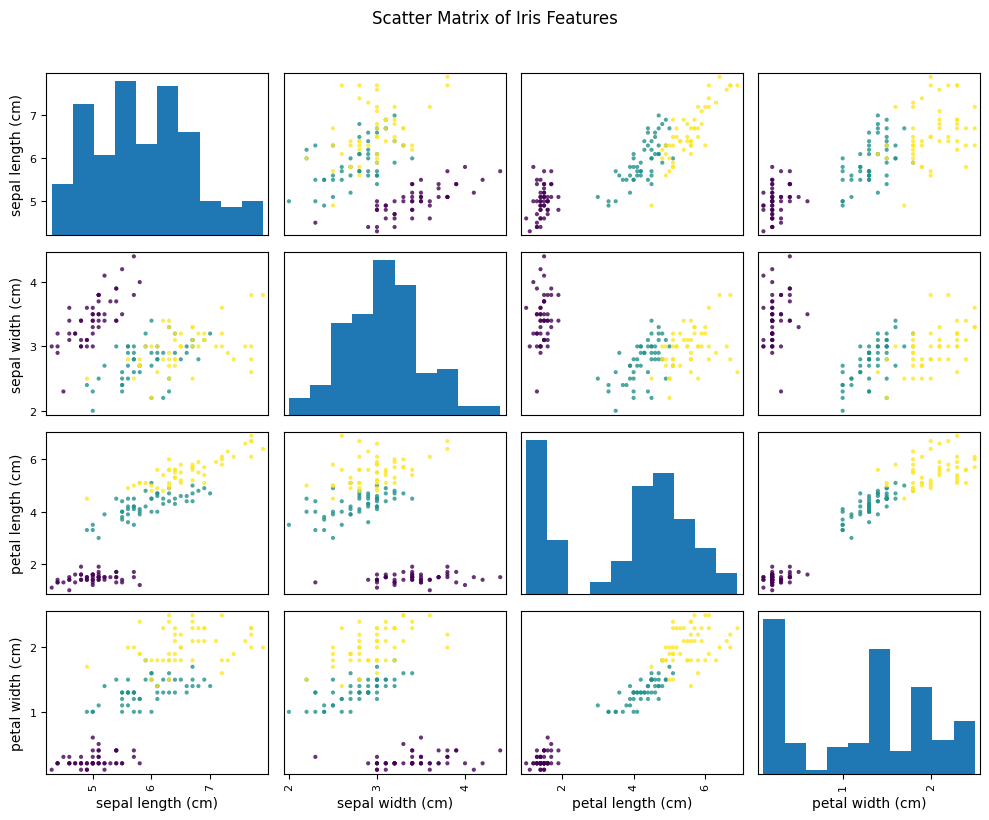

In [5]:
pd.plotting.scatter_matrix(
    df.iloc[:, :4],
    c=df['target'],
    figsize=(10, 8),
    diagonal='hist',
    alpha=0.8,
)
plt.suptitle('Scatter Matrix of Iris Features', y=1.02)
plt.tight_layout()
plt.show()


## 6. Correlation analysis


In [6]:
corr = df.iloc[:, :4].corr()
corr


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


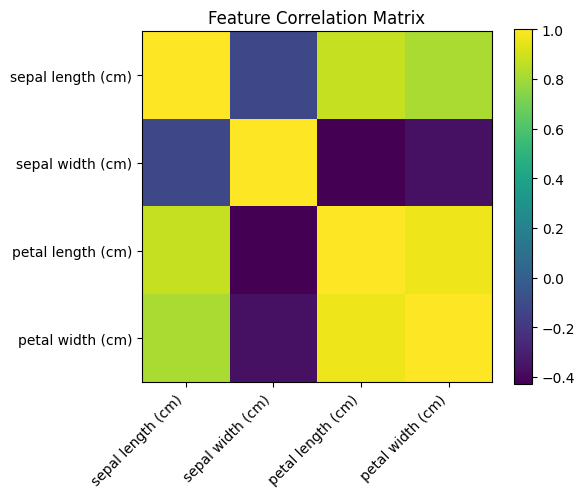

In [7]:
plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 7. Load standardized train/test data


In [8]:
X_train, X_test, y_train, y_test = load_data(test_size=0.2, random_state=42)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Training class counts:', np.bincount(y_train))
print('Test class counts:', np.bincount(y_test))


Training shape: (120, 4)
Test shape: (30, 4)
Training class counts: [40 40 40]
Test class counts: [10 10 10]


## 8. Main experiment: BGD vs SGD vs MBGD


In [9]:
settings = [
    {'optimizer': 'bgd', 'learning_rate': 0.05, 'epochs': 200, 'batch_size': 16},
    {'optimizer': 'sgd', 'learning_rate': 0.01, 'epochs': 200, 'batch_size': 1},
    {'optimizer': 'mbgd', 'learning_rate': 0.03, 'epochs': 200, 'batch_size': 16},
]

histories = []

for cfg in settings:
    _, history = train_model(
        X_train,
        y_train,
        X_test,
        y_test,
        optimizer=cfg['optimizer'],
        learning_rate=cfg['learning_rate'],
        epochs=cfg['epochs'],
        batch_size=cfg['batch_size'],
    )
    histories.append(history)

summary_df = compare_runs(histories)
summary_df


,optimizer,learning_rate,final_train_loss,final_test_loss,final_train_acc,final_test_acc,avg_epoch_time,loss_std
0,bgd,0.05,0.320853,0.364136,0.925000,0.833333,0.000100,0.142892
1,sgd,0.01,0.079440,0.111994,0.975000,0.966667,0.001681,0.078096
2,mbgd,0.03,0.169326,0.214105,0.958333,0.933333,0.000202,0.111898


## 9. Plot convergence and accuracy curves


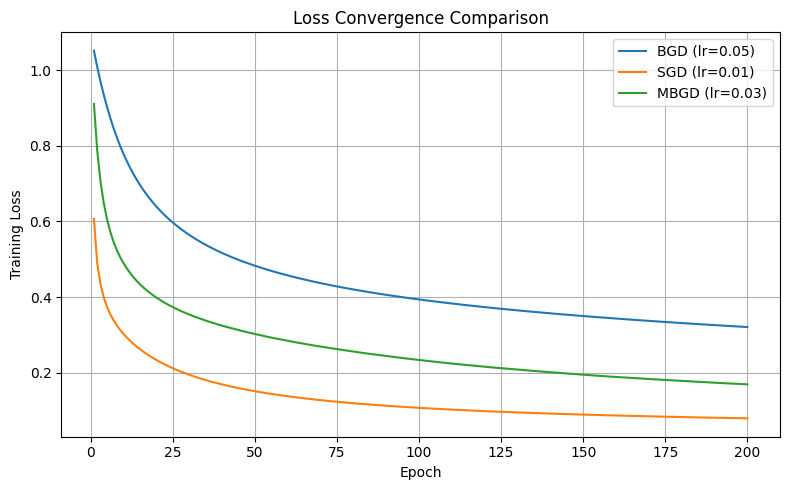

In [10]:
plot_loss_curves(histories)


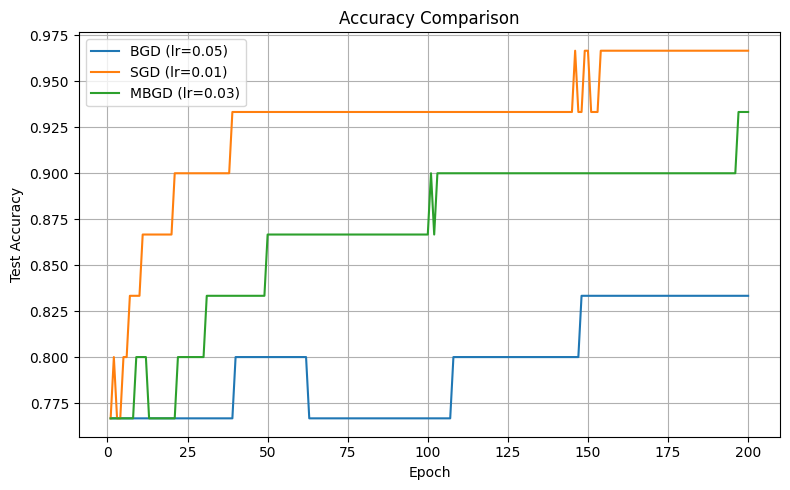

In [11]:
plot_accuracy_curves(histories)


## 10. Learning-rate sensitivity experiment

This section runs a small hyperparameter sweep to show how each optimizer reacts to different learning rates.


In [12]:
lr_grid = {
    'bgd': [0.01, 0.05, 0.1],
    'sgd': [0.001, 0.01, 0.05],
    'mbgd': [0.01, 0.03, 0.05],
}

sweep_rows = []

for optimizer, lr_list in lr_grid.items():
    for lr in lr_list:
        _, history = train_model(
            X_train,
            y_train,
            X_test,
            y_test,
            optimizer=optimizer,
            learning_rate=lr,
            epochs=200,
            batch_size=16 if optimizer != 'sgd' else 1,
        )
        sweep_rows.append({
            'optimizer': optimizer,
            'learning_rate': lr,
            'final_train_loss': history['train_loss'][-1],
            'final_test_loss': history['test_loss'][-1],
            'final_train_acc': history['train_acc'][-1],
            'final_test_acc': history['test_acc'][-1],
            'avg_epoch_time': np.mean(history['epoch_time']),
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.sort_values(['optimizer', 'learning_rate']).reset_index(drop=True)


,optimizer,learning_rate,final_train_loss,final_test_loss,final_train_acc,final_test_acc,avg_epoch_time
0,bgd,0.010,0.518640,0.545970,0.850000,0.800000,0.000111
1,bgd,0.050,0.320853,0.364136,0.925000,0.833333,0.000109
2,bgd,0.100,0.251871,0.297899,0.933333,0.866667,0.000101
3,mbgd,0.010,0.274479,0.319981,0.925000,0.866667,0.000199
4,mbgd,0.030,0.169326,0.214105,0.958333,0.933333,0.000198
5,mbgd,0.050,0.130785,0.172554,0.966667,0.933333,0.000198
6,sgd,0.001,0.234178,0.280417,0.933333,0.866667,0.001652
7,sgd,0.010,0.079440,0.111994,0.975000,0.966667,0.001646
8,sgd,0.050,0.050110,0.066994,0.975000,1.000000,0.001642


## 11. Visualize test accuracy across learning rates


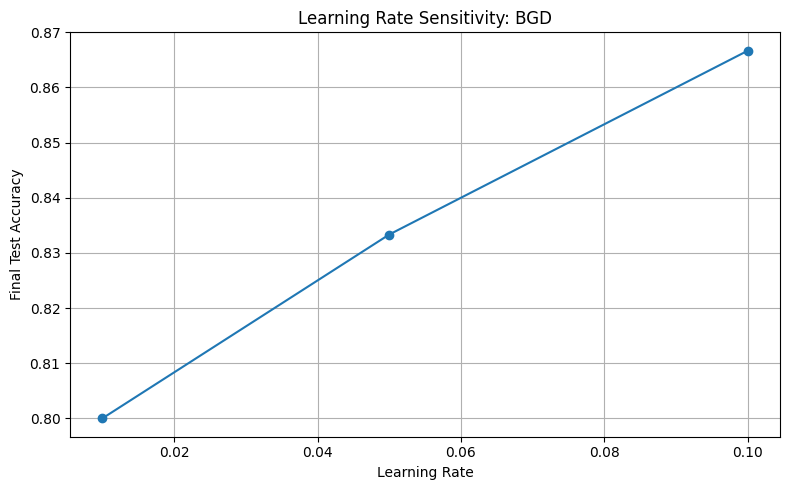

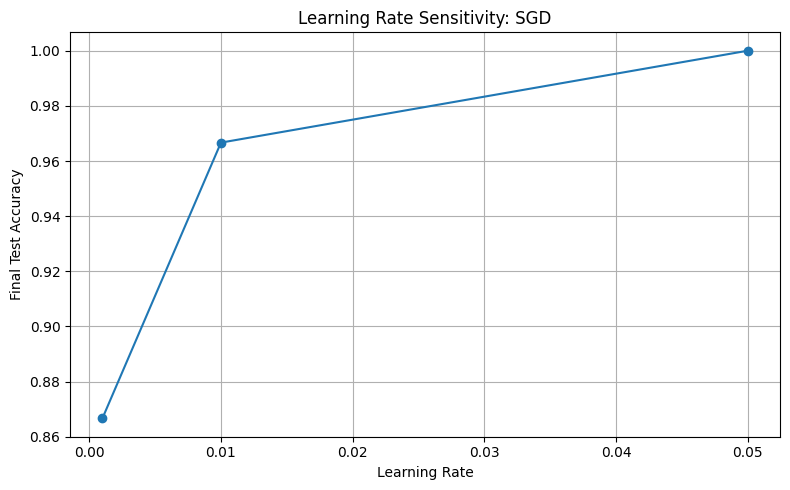

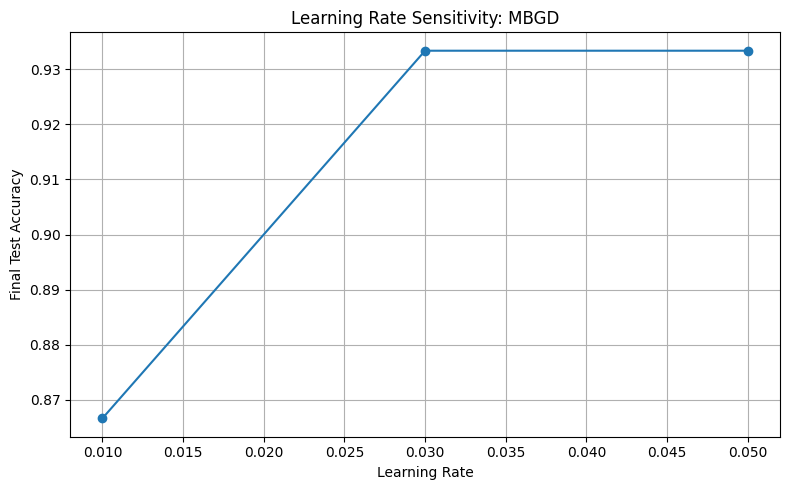

In [13]:
for optimizer in ['bgd', 'sgd', 'mbgd']:
    subset = sweep_df[sweep_df['optimizer'] == optimizer].sort_values('learning_rate')
    plt.figure()
    plt.plot(subset['learning_rate'], subset['final_test_acc'], marker='o')
    plt.xlabel('Learning Rate')
    plt.ylabel('Final Test Accuracy')
    plt.title(f'Learning Rate Sensitivity: {optimizer.upper()}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 12. Short interpretation notes

You can adapt the following observations after running the notebook:

- All three optimization methods converge on the Iris dataset.
- SGD often reaches lower loss faster in epoch-based comparison because it updates parameters more frequently.
- BGD tends to be smoother but slower.
- MBGD usually provides a compromise between computational efficiency and predictive performance.
- Learning rate strongly affects both convergence speed and final accuracy.
